# ___Environmental properties___
-----------------------

In [1]:
!python --version

Python 3.14.0


The system cannot find the path specified.


In [2]:
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Patch
from bs4 import BeautifulSoup

In [9]:
SITE_CODE_LOOKUP = {
    "TT4": "A", # Virginia Gardens_SA
    "TT6": "B", # Dalby_QLD
    "TT7": "C", # Sydney
    "TT13": "D", # Mt Fox N Park_QLD
    "TT15": "E", # Panawonica_WA
    "TT17": "F" # Rainbow Valley_NT
}

In [45]:
# IN EMMA'S DATASET, THE SITE NAMES ARE ALL FUCKED UP!!!!!! (STATE, SITE, COORDINATES ETC.)
themeda = pd.read_csv(r"../../data/chapter3/CSBP_soil_analysis_Themeda_and_Sorghum.csv", skiprows=range(20, 35)).drop(0, axis=0)
themeda = themeda.rename(mapper= lambda name: name.lower().strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'prcnt'), axis=1)
themeda = themeda.astype({"total_nitrogen": np.float64, "total_phosphorus": np.float64, "total_carbon": np.float64, "prcnt_clay": np.float64, "prcnt_course_sand": np.float64, "prcnt_fine_sand": np.float64, "prcnt_sand": np.float64, "prcnt_silt": np.float64})
themeda_subset = themeda.query("customer_sample_id.isin(@SITE_CODE_LOOKUP.keys())").copy()
themeda_subset.loc[:, "site"] = themeda_subset.customer_sample_id.replace(SITE_CODE_LOOKUP)

meterology = pd.read_csv(r"../../data/chapter3/site_metereology.csv", header=2).drop(index=[2, 3]).reset_index(drop=True)
meterology.loc[:, "site"] = meterology.site_code_emma.replace(SITE_CODE_LOOKUP)
meterology = meterology.sort_values(by="site", ignore_index=True) #, key=lambda col: col.str.replace("TT", '').astype(int))

In [7]:
themeda_subset.total_nitrogen # w/w %

4     0.11
6     0.18
7     0.03
13    0.05
15    0.15
17    0.09
Name: total_nitrogen, dtype: float64

In [10]:
# w/w is w/w % divided by 100
themeda_subset.total_nitrogen / 100

4     0.0011
6     0.0018
7     0.0003
13    0.0005
15    0.0015
17    0.0009
Name: total_nitrogen, dtype: float64

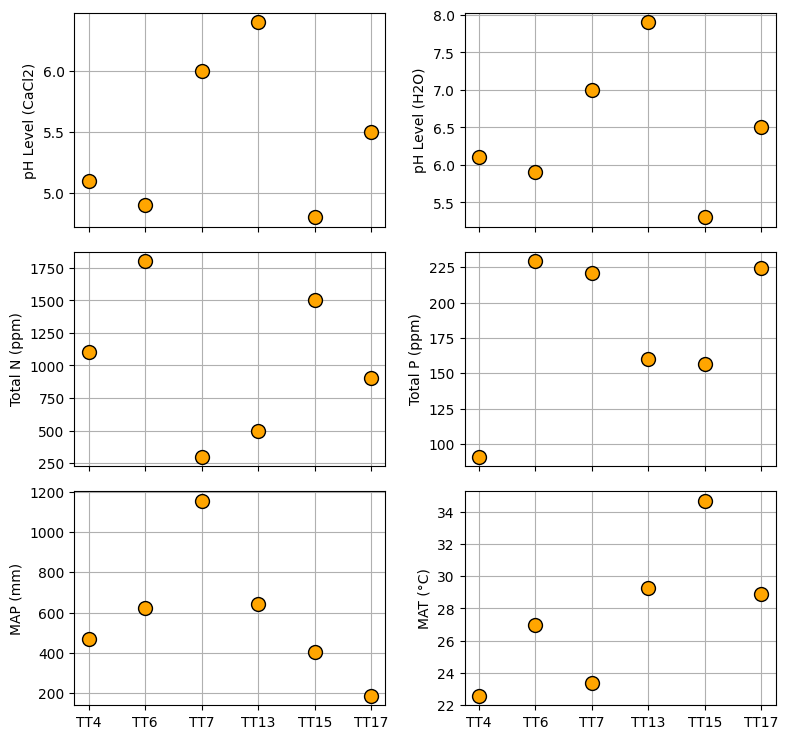

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=2, sharex=True, sharey=False)
fig.set_size_inches(8, 7.5)

for (prop, name, axis) in zip(("ph_level_cacl2", "ph_level_h2o", "total_nitrogen", "total_phosphorus"), ("pH Level (CaCl2)", "pH Level (H2O)", "Total N (ppm)", "Total P (ppm)"), axes.flatten()[:4]):
    # if total_nitrogen, convert to mg/kg (ppm) from w/w %
    if prop == "total_nitrogen":
        axis.plot(themeda_subset.customer_sample_id, themeda_subset.total_nitrogen / 100 * 1e6, # / 100 -> w/w% to w/w, * 1e6 -> w/w to ppm
                  linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    else:
        axis.plot(themeda_subset.customer_sample_id, themeda_subset[prop], linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    axis.grid()
    axis.set_ylabel(name)

# in the bottom two grids, plot MAT and MAP
for (prop, name, axis) in zip(("annual_rainfall_mm", "mean_annual_temp_celsius"), ("MAP (mm)", "MAT (°C)"), axes.flatten()[4:]):
    axis.plot(meterology.site_code_emma, meterology[prop], linestyle="none", marker='o', mec="black", mfc="orange", markersize=10)
    axis.grid()
    axis.set_ylabel(name)

plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/themeda_site_props.png", dpi=500, transparent=True)

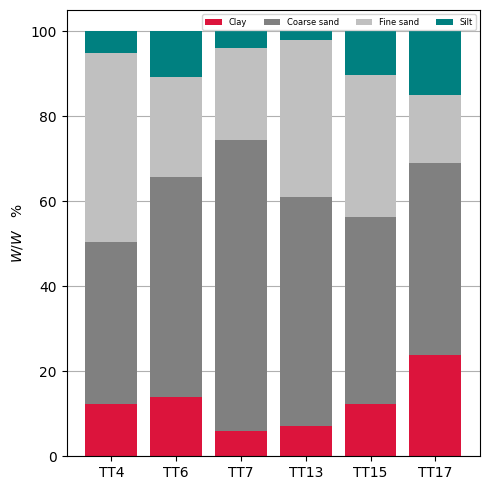

In [5]:
# SOIL TEXTURE 

fig, axes = plt.subplots()
fig.set_size_inches(5, 5)

axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_clay, color="crimson", label="Clay")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_course_sand, bottom=themeda_subset.prcnt_clay, color="grey", label="Coarse sand")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_fine_sand, bottom=themeda_subset.prcnt_clay+themeda_subset.prcnt_course_sand, color="silver", label="Fine sand")
axes.bar(x=themeda_subset.customer_sample_id, height=themeda_subset.prcnt_silt, bottom=themeda_subset.prcnt_clay+themeda_subset.prcnt_sand, color="teal", label="Silt")
axes.set_axisbelow(True)
axes.grid(axis='y')
axes.legend(loc="upper right", ncols=4, fontsize=6)
axes.set_ylabel(r"$W/W\hspace{1}\%$")    
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/emma_themeda_subset_soil_texture.jpeg", dpi=500)

In [10]:
themeda_subset.loc[:, ["customer_sample_id", "latitude", "longitude"]]

,customer_sample_id,latitude,longitude
4,TT4,-34.784167,138.696667
6,TT6,-27.156601,151.235198
7,TT7,-33.629080,151.113020
13,TT13,-19.001291,145.473311
15,TT15,-21.637977,116.334303
17,TT17,-24.235000,133.459000


In [25]:
# coordinates from Emma's work and Vin's work are quite identical :)
pd.merge(left=themeda_subset, left_on="customer_sample_id", right=meterology, right_on="site_code_emma").loc[:, ["latitude_x", "longitude_x", "latitude_y", "longitude_y"]]

,latitude_x,longitude_x,latitude_y,longitude_y
0,-34.784167,138.696667,-34.853889,138.620556
1,-27.156601,151.235198,-27.114868,151.181761
2,-33.629080,151.113020,-33.688102,151.062410
3,-19.001291,145.473311,-19.001300,145.473117
4,-21.637977,116.334303,-21.644900,116.323300
5,-24.235000,133.459000,-24.237644,133.553612


In [26]:
pd.merge(left=themeda_subset, left_on="customer_sample_id", right=meterology, right_on="site_code_emma").loc[:, ["latitude_x", "longitude_x", "latitude_y", "longitude_y"]].corr()

,latitude_x,longitude_x,latitude_y,longitude_y
latitude_x,1.000000,-0.389731,0.999989,-0.387642
longitude_x,-0.389731,1.000000,-0.387944,0.999991
latitude_y,0.999989,-0.387944,1.000000,-0.385854
longitude_y,-0.387642,0.999991,-0.385854,1.000000


In [46]:
meterology

,site,state,latitude,longitude,site_code_emma,annual_rainfall_weather_station,annual_rainfall_station_id,annual_rainfall_distance_from_site_km,annual_rainfall_mm,mean_annual_temp_weather_station,mean_annual_temp_station_id,mean_annual_temp_distance_from_site_km,mean_annual_temp_celsius
0,A,SA,-34.853889,138.620556,TT4,Greenacres,23133,2.22,468.7,Parafield Airport,23013,6.25,22.6
1,B,QLD,-27.114868,151.181761,TT6,Hereward,41240,8.77,621.4,Dalby Airport,41522,9.48,27.0
2,C,NSW,-33.688102,151.062410,TT7,Hornsby Swimming Pool,67065,3.42,1156.9,Parramatta North,66124,12.16,23.4
3,D,QLD,-19.001300,145.473117,TT13,Christmas Creek Station,32104,16.19,642.8,Ingham Composite,32078,83.07,29.3
4,E,WA,-21.644900,116.323300,TT15,Panawonica,5069,1.00,404.4,Panawonica,5069,1.00,34.7
5,F,NT,-24.237644,133.553612,TT17,Hugh River,15676,14.31,189.3,Alice Springs Airport,15590,59.52,28.9


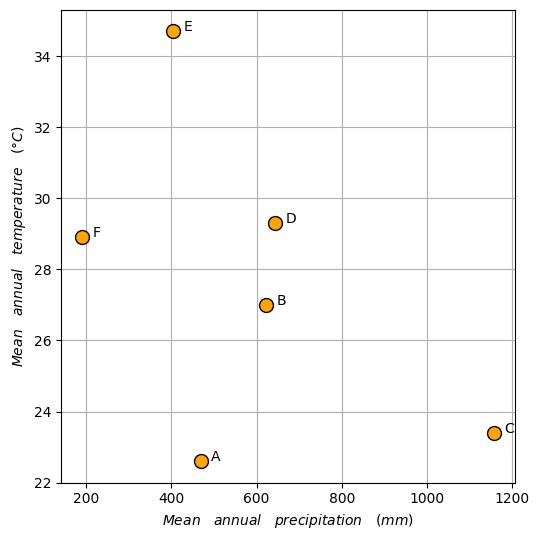

In [71]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 5.5)
axes.scatter(meterology.annual_rainfall_mm, meterology.mean_annual_temp_celsius, edgecolor="black", color="orange", s=100)
for _, (site, _map, mat) in meterology.loc[:, ["site", "annual_rainfall_mm", "mean_annual_temp_celsius"]].iterrows():
    axes.text(_map+25, mat, s=site)
axes.set_xlabel(r"$Mean\hspace{1}annual\hspace{1}precipitation\hspace{1}(mm)$")
axes.set_ylabel(r"$Mean\hspace{1}annual\hspace{1}temperature\hspace{1}(°C)$")
axes.grid(visible=True, which="both", alpha=1)
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/matmap6.png", format=r"png", dpi=500)

In [82]:
themeda_subset

,lab_number,date_received,customer_sample_id,sample_name_1,sample_name_2,latitude,longitude,depth,colour,gravel_percent,...,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_course_sand,prcnt_fine_sand,prcnt_sand,prcnt_silt,site
4,2KGS24027,12/09/2024,TT4,CHS VIC,Condah Hotspur Rd Vic,-34.784167,138.696667,0-10,GRBR,5,...,6.1,0.11,91.0,1.56,12.22,38.15,44.51,82.66,5.11,A
6,2KGS24029,12/09/2024,TT6,HH NSW,Hornsby Heights NSW,-27.156601,151.235198,0-10,DKBR,5-Oct,...,5.9,0.18,229.2,4.04,13.88,51.89,23.51,75.40,10.72,B
7,2KGS24030,12/09/2024,TT7,JIN NSW,Jindabyne NSW,-33.629080,151.113020,0-10,YWGR,5,...,7.0,0.03,221.2,0.53,5.98,68.36,21.64,90.00,4.02,C
13,2KGS24037,12/09/2024,TT13,PV NT,Palm Valley NT,-19.001291,145.473311,0-10,BROR,0,...,7.9,0.05,160.1,0.68,7.10,53.97,36.89,90.86,2.04,D
15,2KGS24039,12/09/2024,TT15,POW TAS,Powranna TAS,-21.637977,116.334303,0-10,GRBR,5-Oct,...,5.3,0.15,156.5,2.65,12.40,43.88,33.34,77.22,10.38,E
17,2KGS24041,12/09/2024,TT17,TLJ QLD,The Lynd Junction QLD,-24.235000,133.459000,0-10,GRBR,35-40,...,6.5,0.09,224.8,1.89,23.85,45.11,16.11,61.22,14.94,F


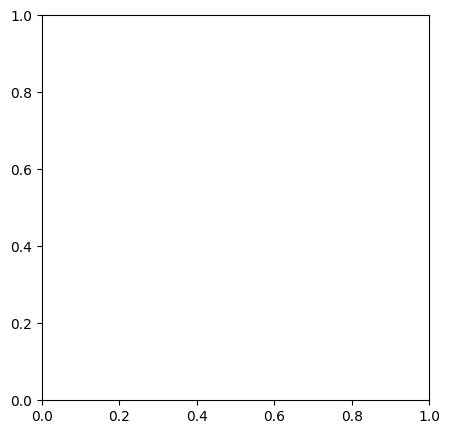

In [81]:
fig, axes = plt.subplots()
fig.set_size_inches(5, 5)
axis.scatter(themeda_subset.ph_level_h2o, themeda_subset.total_phosphorus, edgecolor="black", color="orange", s=100)
plt.show()